In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import chex
from functools import partial
from typing import Callable
import os
from exciting_environments import PMSM, IM
import matplotlib.pyplot as plt
import jax_dataclasses as jdc
from exciting_environments.utils import MinMaxNormalization
jax.config.update("jax_enable_x64", True) 

2026-02-27 12:32:11.010783: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [ ]:
# from functools import partial
# from typing import Callable
# from types import MethodType
# import numpy as np
# import jax
# import jax.numpy as jnp
# from jax.tree_util import tree_flatten, tree_unflatten, tree_structure, tree_map
# import jax_dataclasses as jdc
# import chex
# import diffrax
# from scipy.interpolate import griddata
# from jax.scipy.linalg import expm
# from dataclasses import fields

# from copy import deepcopy

# from exciting_environments import CoreEnvironment
# from exciting_environments.im import default_params

# import numpy as np
# from scipy.linalg import expm
# import jaxopt

# # only for alpha/beta -> abc
# t32 = jnp.array([[1, 0], [-0.5, 0.5 * jnp.sqrt(3)], [-0.5, -0.5 * jnp.sqrt(3)]])
# t23 = 2 / 3 * jnp.array([[1, 0], [-0.5, 0.5 * jnp.sqrt(3)], [-0.5, -0.5 * jnp.sqrt(3)]]).T  # only for abc -> alpha/beta

# inverter_t_abc = jnp.array(
#     [
#         [-0.5, -0.5, -0.5],
#         [0.5, -0.5, -0.5],
#         [0.5, 0.5, -0.5],
#         [-0.5, 0.5, -0.5],
#         [-0.5, 0.5, 0.5],
#         [-0.5, -0.5, 0.5],
#         [0.5, -0.5, 0.5],
#         [0.5, 0.5, 0.5],
#     ]
# )

# ROTATION_MAP = np.ones((2, 2, 2), dtype=np.complex64)
# ROTATION_MAP[1, 0, 1] = 0.5 * (1 + np.sqrt(3) * 1j)
# ROTATION_MAP[1, 1, 0] = 0.5 * (1 - np.sqrt(3) * 1j)
# ROTATION_MAP[0, 1, 0] = 0.5 * (-1 - np.sqrt(3) * 1j)
# ROTATION_MAP[0, 1, 1] = -1
# ROTATION_MAP[0, 0, 1] = 0.5 * (-1 + np.sqrt(3) * 1j)
# ROTATION_MAP = jnp.array(ROTATION_MAP)


# def t_dq_alpha_beta(eps):
#     """Compute the transformation matrix for converting between DQ and Alpha-Beta reference frames."""
#     cos = jnp.cos(eps)
#     sin = jnp.sin(eps)
#     return jnp.column_stack((cos, sin, -sin, cos)).reshape(2, 2)


# def dq2abc(u_dq, eps):
#     """Transform voltages from DQ coordinates to ABC (three-phase) coordinates."""
#     u_abc = t32 @ dq2albet(u_dq, eps).T
#     return u_abc.T


# def dq2albet(u_dq, eps):
#     """Transform voltages from DQ coordinates to Alpha-Beta coordinates."""
#     q = t_dq_alpha_beta(-eps)
#     u_alpha_beta = q @ u_dq.T

#     return u_alpha_beta.T


# def albet2dq(u_albet, eps):
#     """Transform voltages from Alpha-Beta coordinates to DQ coordinates."""
#     q_inv = t_dq_alpha_beta(eps)
#     u_dq = q_inv @ u_albet.T

#     return u_dq.T


# def abc2dq(u_abc, eps):
#     """Transform voltages from ABC (three-phase) coordinates to DQ coordinates."""
#     u_alpha_beta = t23 @ u_abc.T
#     u_dq = albet2dq(u_alpha_beta.T, eps)
#     return u_dq


# def step_eps(eps, omega_el, tau, tau_scale=1.0):
#     """Update the electrical angle over a time step with optional scaling."""
#     eps += omega_el * tau * tau_scale
#     eps %= 2 * jnp.pi
#     boolean = eps > jnp.pi
#     summation_mask = boolean * -2 * jnp.pi
#     eps = eps + summation_mask
#     return eps


# def apply_hex_constraint(u_albet):
#     """Clip voltages in alpha/beta coordinates into the voltage hexagon."""
#     u_albet_c = u_albet[0] + 1j * u_albet[1]
#     idx = (jnp.sin(jnp.angle(u_albet_c)[..., jnp.newaxis] - 2 / 3 * jnp.pi * jnp.arange(3)) >= 0).astype(int)
#     rot_vec = ROTATION_MAP[idx[0], idx[1], idx[2]]
#     # rotate sectors upwards
#     u_albet_c = jnp.multiply(u_albet_c, rot_vec)
#     u_albet_c = jnp.clip(u_albet_c.real, -2 / 3, 2 / 3) + 1j * u_albet_c.imag
#     u_albet_c = u_albet_c.real + 1j * jnp.clip(u_albet_c.imag, 0, 2 / 3 * jnp.sqrt(3))
#     u_albet_c = jnp.multiply(u_albet_c, jnp.conjugate(rot_vec))  # rotate back
#     return jnp.column_stack([u_albet_c.real, u_albet_c.imag])


# # def clip_in_abc_coordinates(u_dq, u_dc, omega_el, eps, tau):
# #     """Clip voltages in ABC (three-phase) coordinates and transform back to DQ coordinates."""
# #     eps_advanced = step_eps(eps, omega_el, tau, 0.5)
# #     u_abc = dq2abc(u_dq, eps_advanced)
# #     # clip in abc coordinates
# #     u_abc = jnp.clip(u_abc, -u_dc / 2.0, u_dc / 2.0)
# #     u_dq = abc2dq(u_abc, eps)
# #     return u_dq


# class IM(CoreEnvironment):
#     def __init__(
#         self,
#         batch_size: int = 8,
#         saturated=False,
#         motor_name: str = None,
#         physical_normalizations: dict = None,
#         action_normalizations: dict = None,
#         soft_constraints: Callable = None,
#         static_params: dict = None,
#         control_state: list = None,
#         exact_discretization: bool = False,  # problems with GPU
#         solver=diffrax.Heun(),
#         tau: float = 1e-4,
#     ):
#         """
#         Args:
#             batch_size (int): Number of parallel environment simulations. Default: 8
#             saturated (bool): l_m and l_sigr are taken from motor_name specific LUTs. Default: False
#             motor_name (str): Sets physical_normalizations, action_normalizations, soft_constraints and static_params to default values for the passed motor name and stores associated LUTs for the possible saturated case. Needed if saturated==True.
#             physical_normalizations (dict): min-max normalization values of the physical state of the environment.
#                 u_alpha_buffer (MinMaxNormalization): Voltage in alpha axis of the delayed action due to system deadtime. Default: min=-2 * 560 / 3, max=2 * 560 / 3
#                 u_beta_buffer (MinMaxNormalization): Voltage in beta axis of the delayed action due to system deadtime. Default: min=-2 * 560 / 3, max=2 * 560 / 3
#                 epsilon (MinMaxNormalization): Electrical rotor rotation angle. Default: min=-jnp.pi, max=jnp.pi
#                 i_s_alpha(MinMaxNormalization): Stator current in alpha axis. Default: min=-20, max=20
#                 i_s_beta (MinMaxNormalization): Stator current in beta axis. Default: min=-20, max=20
#                 omega_el (MinMaxNormalization): Electrical rotor angular velocity. Default: min=0, max=2 * 5000 * 2 * jnp.pi / 60
#                 torque (MinMaxNormalization): Torque caused by the current. Default: min=-20, max=20
#             action_normalizations (dict): min-max normalization values of the input/action.
#                 u_alpha(MinMaxNormalization): Voltage in alpha axis. Default: min=-2 * 560 / 3, max=2 * 560 / 3
#                 u_beta (MinMaxNormalization): Voltage in beta axis. Default: min=-2 * 560 / 3, max=2 * 560 / 3
#             soft_constraints (Callable): Function that returns soft constraints values for state and/or action.
#             static_params (dict): Parameters of environment which do not change during simulation.
#                 p (int): Pole pair number. Default: 2
#                 r_s (float): Stator resistance. Default: 2.9338
#                 r_r (float): Rotor resistance. Default: 1.355
#                 l_m (float): Main inductance. Default: 143.75e-3
#                 l_sigs (float): Stator-side stray inductance. Default: 5.87e-3
#                 l_sigr (float): Rotor-side stray inductance. Default: 5.87e-3
#                 u_dc (float): DC link voltage. Default: 560
#                 deadtime (int): Delay between passed and performed action on the system. Default: 0
#             control_state: Components of the physical state that are considered in reference tracking.
#             solver (diffrax.solver): Solver used to compute state for next step.
#             tau (float): Duration of one control/simulation step in seconds. Default: 1e-4.

#         Note: Attributes of MinMaxNormalization of physical_normalizations and action_normalizations as well as static_params can also be
#             passed as jnp.Array with the length of the batch_size to set different values per batch.
#         """
#         self.batch_size = batch_size
#         self.tau = tau
#         self._solver = solver
#         self.exact_discretization = exact_discretization

#         motor_params = deepcopy(default_params(motor_name))
#         default_physical_normalizations = motor_params.physical_normalizations.__dict__
#         default_action_normalizations = motor_params.action_normalizations.__dict__
#         default_static_params = motor_params.static_params.__dict__
#         default_soft_constraints = MethodType(motor_params.default_soft_constraints, self)
#         saturation_params = motor_params.saturation_params
#         if saturated:
#             self.saturation_interpolators = self.generate_saturation_interpolators(
#                 saturation_params, motor_params.physical_normalizations
#             )

#         else:
#             saturated_quants = [
#                 "l_m",
#                 "l_sigr",
#             ]
#             self.saturation_interpolators = {q: lambda x: jnp.array([np.nan]) for q in saturated_quants}

#         if not static_params:
#             static_params = default_static_params

#         if not physical_normalizations:
#             physical_normalizations = default_physical_normalizations
#         else:
#             i_s_alpha_lims = physical_normalizations["i_s_alpha"]
#             i_s_beta_lims = physical_normalizations["i_s_beta"]
#             def_i_s_alpha_lims = default_physical_normalizations["i_s_alpha"]
#             def_i_s_beta_lims = default_physical_normalizations["i_s_beta"]

#             if (i_s_alpha_lims.min < def_i_s_alpha_lims.min) or (i_s_alpha_lims.max > def_i_s_alpha_lims.max):
#                 print(
#                     f"The defined permitted range of i_s_alpha ({i_s_alpha_lims}) exceeds the limits set in the motor parameters corresponding to motor_name."
#                 )
#             if (i_s_beta_lims.min < def_i_s_beta_lims.min) or (i_s_beta_lims.max > def_i_s_beta_lims.max):
#                 print(
#                     f"The defined permitted range of i_s_beta ({i_s_beta_lims}) exceeds the limits set in the motor parameters corresponding to motor_name."
#                 )

#         if not action_normalizations:
#             action_normalizations = default_action_normalizations

#         if not control_state:
#             control_state = []

#         if not soft_constraints:
#             soft_constraints = default_soft_constraints

#         self.control_state = control_state
#         self.soft_constraints = soft_constraints

#         static_params = self.StaticParams(**static_params)
#         physical_normalizations = self.PhysicalState(**physical_normalizations)
#         action_normalizations = self.Action(**action_normalizations)

#         env_properties = self.EnvProperties(
#             saturated=saturated,
#             physical_normalizations=physical_normalizations,
#             action_normalizations=action_normalizations,
#             static_params=static_params,
#         )
#         super().__init__(batch_size, env_properties=env_properties, tau=tau, solver=solver)

#         self._action_description = ["u_alpha", "u_beta"]
#         self._obs_description = [
#             "i_s_alpha",
#             "i_s_beta",
#             "psi_r_alpha",
#             "psi_r_beta",
#             "omega_el",
#             "torque",
#             "cos_eps",
#             "sin_eps",
#             "u_alpha_buffer",
#             "u_beta_buffer",
#         ]

#         if exact_discretization:
#             A_d, B_d = self.get_discrete_matrices(env_properties)
#             self.A_d = jnp.array(A_d)
#             self.B_d = jnp.array(B_d)

#     @jdc.pytree_dataclass
#     class StaticParams:
#         """Dataclass containing the physical parameters of the environment."""

#         p: jax.Array
#         r_s: jax.Array
#         r_r: jax.Array
#         r_fe: jax.Array
#         l_m: jax.Array
#         l_sigs: jax.Array
#         l_sigr: jax.Array
#         u_dc: jax.Array
#         deadtime: jax.Array


#     @jdc.pytree_dataclass
#     class PhysicalState:
#         """Dataclass containing the physical state of the environment."""

#         u_alpha_buffer: jax.Array
#         u_beta_buffer: jax.Array
#         i_s_alpha: jax.Array
#         i_s_beta: jax.Array
#         psi_r_alpha: jax.Array
#         psi_r_beta: jax.Array
#         epsilon: jax.Array
#         omega_el: jax.Array
#         torque: jax.Array
#         i_sl_alpha: jax.Array
#         i_sl_beta: jax.Array

#     @jdc.pytree_dataclass
#     class PhysicalStateSat:
#         """Dataclass containing the physical state of the environment."""

#         u_alpha_buffer: jax.Array
#         u_beta_buffer: jax.Array
#         i_s_alpha: jax.Array
#         i_s_beta: jax.Array
#         psi_r_alpha: jax.Array
#         psi_r_beta: jax.Array
#         epsilon: jax.Array
#         omega_el: jax.Array
#         torque: jax.Array

#     @jdc.pytree_dataclass
#     class Additions:
#         """Dataclass containing additional information for simulation."""

#         solver_state: tuple
#         active_solver_state: bool

#     @jdc.pytree_dataclass
#     class Action:
#         """Dataclass containing the action, that can be applied to the environment."""

#         u_alpha: jax.Array
#         u_beta: jax.Array

#     @jdc.pytree_dataclass
#     class EnvProperties:
#         """Dataclass used for simulation which contains environment specific dataclasses."""

#         saturated: jax.Array
#         physical_normalizations: jdc.pytree_dataclass
#         action_normalizations: jdc.pytree_dataclass
#         static_params: jdc.pytree_dataclass

#     def currents_to_torque(self, i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta, env_properties):
#         torque = (
#             1.5
#             * env_properties.static_params.p
#             * env_properties.static_params.l_m
#             / (env_properties.static_params.l_m + env_properties.static_params.l_sigr)
#             * (psi_r_alpha * i_s_beta - psi_r_beta * i_s_alpha)
#         )
#         return torque

#     def get_L_saturated(self, i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta):
#         ax, ay = psi_r_alpha, psi_r_beta
#         bx, by = i_s_alpha, i_s_beta
#         psi_r_mag = jnp.sqrt(ax * ax + ay * ay)
#         i_s_mag = jnp.sqrt(bx * bx + by * by)
#         cross = ax * by - ay * bx
#         dot = ax * bx + ay * by
#         angle = jnp.abs(jnp.atan2(cross, dot))

#         # query_point = jnp.array([angle, psi_r_mag, i_s_mag])

#         # l_m_sat = self.saturation_interpolators["l_m"](query_point)
#         # l_sigr_sat = self.saturation_interpolators["l_sigr"](query_point)
#         query_point = jnp.stack([angle, psi_r_mag, i_s_mag])[None, :]
#         l_m_sat = self.saturation_interpolators["l_m"](query_point)[0]
#         l_sigr_sat = self.saturation_interpolators["l_sigr"](query_point)[0]
#         return l_m_sat, l_sigr_sat

#     def currents_to_torque_sat(self, i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta, env_properties):
#         l_m_sat, l_sigr_sat = self.get_L_saturated(i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta)
#         torque = (
#             1.5
#             * env_properties.static_params.p
#             * l_m_sat
#             / (l_m_sat + l_sigr_sat)
#             * (psi_r_alpha * i_s_beta - psi_r_beta * i_s_alpha)
#         )
#         return torque

#     def calc_flux_magnitudes(self, L_vec, i_s_ab, psi_r_ab):
#         lm_sat, lsigr_sat = L_vec
#         i_r_ab = (psi_r_ab - lm_sat * i_s_ab) / (lm_sat + lsigr_sat)

#         psi_sigr_mag = jnp.linalg.norm(lsigr_sat * i_r_ab)
#         psi_m_mag = jnp.linalg.norm(lm_sat * (i_s_ab + i_r_ab))
#         return psi_m_mag, psi_sigr_mag, i_r_ab

#     def saturation_residuals_vector(self, L_vec, i_s_ab, psi_r_ab, params):
#         lm_sat, lsigr_sat = L_vec
#         psi_m_mag, psi_sigr_mag, i_r_ab = self.calc_flux_magnitudes(L_vec, i_s_ab, psi_r_ab)
#         params = params.__dict__
#         lm_new = params["l_m_u"] / (
#             1
#             + params["alpha"] * psi_m_mag ** params["a"]
#             + params["gamma"]
#             * params["l_m_u"]
#             / (params["d"] + 2)
#             * psi_m_mag ** params["c"]
#             * psi_sigr_mag ** (params["d"] + 2)
#         )

#         lsigr_new = params["l_sigr_u"] / (
#             1
#             + params["beta"] * psi_sigr_mag ** params["b"]
#             + params["gamma"]
#             * params["l_sigr_u"]
#             / (params["c"] + 2)
#             * psi_sigr_mag ** params["d"]
#             * psi_m_mag ** (params["c"] + 2)
#         )

#         return jnp.array([lm_sat - lm_new, lsigr_sat - lsigr_new])

#     def generate_saturation_interpolators(self, saturation_params, physical_normalizations):
#         i_s_max = physical_normalizations.i_s_alpha.max
#         psi_r_max = physical_normalizations.psi_r_alpha.max
#         n_res = 50
#         i_s_grid_1d = jnp.linspace(0.0, i_s_max * 1.25, n_res)
#         psi_r_grid_1d = jnp.linspace(0.0, psi_r_max * 1.25, n_res)
#         angle_grid_1d = jnp.linspace(0, jnp.pi, n_res)

#         @jax.jit
#         def solve_single_point(i_s_mag, psi_r_mag, angle, params):
#             i_s_ab = jnp.array([i_s_mag, 0.0])
#             psi_r_ab = jnp.array([psi_r_mag * jnp.cos(angle), psi_r_mag * jnp.sin(angle)])

#             def root_fun(L_vec):
#                 return self.saturation_residuals_vector(L_vec, i_s_ab, psi_r_ab, params)

#             solver = jaxopt.Broyden(fun=root_fun, maxiter=100, tol=1e-6)
#             init_L = jnp.array([params.l_m_u, params.l_sigr_u])
#             sol = solver.run(init_L)
#             L_final = sol.params

#             psi_m_mag, psi_sigr_mag, i_r_ab = self.calc_flux_magnitudes(L_final, i_s_ab, psi_r_ab)

#             i_m_mag = jnp.linalg.norm(i_s_ab + i_r_ab)
#             i_r_mag = jnp.linalg.norm(i_r_ab)

#             return jnp.array(
#                 [L_final[0], L_final[1], psi_m_mag, psi_sigr_mag, i_m_mag, i_r_mag, i_s_mag, psi_r_mag, angle]
#             )

#         v_solve = jax.vmap(
#             jax.vmap(jax.vmap(solve_single_point, in_axes=(0, None, None, None)), in_axes=(None, 0, None, None)),
#             in_axes=(None, None, 0, None),
#         )
#         grid_results = v_solve(i_s_grid_1d, psi_r_grid_1d, angle_grid_1d, saturation_params)

#         lm_grid = grid_results[:, :, :, 0]
#         lsigr_grid = grid_results[:, :, :, 1]

#         points = (angle_grid_1d, psi_r_grid_1d, i_s_grid_1d)

#         saturation_interpolators = {
#             "l_m": jax.scipy.interpolate.RegularGridInterpolator(
#                 points, lm_grid, method="linear", bounds_error=False, fill_value=None
#             ),
#             "l_sigr": jax.scipy.interpolate.RegularGridInterpolator(
#                 points, lsigr_grid, method="linear", bounds_error=False, fill_value=None
#             ),
#         }

#         return saturation_interpolators

#     def init_state(self, env_properties, rng: chex.PRNGKey = None, vmap_helper=None):
#         """Returns default initial state for all batches."""
#         if rng is None:
#             phys = self.PhysicalState(
#                 u_alpha_buffer=0.0,
#                 u_beta_buffer=0.0,
#                 epsilon=0.0,
#                 i_s_alpha=0.0,
#                 i_s_beta=0.0,
#                 psi_r_alpha=0.0,
#                 psi_r_beta=0.0,
#                 torque=0.0,
#                 omega_el=(
#                     env_properties.physical_normalizations.omega_el.min
#                     + env_properties.physical_normalizations.omega_el.max
#                 )
#                 / 2,
#             )

#             rng = jnp.nan
#         else:
#             # raise NotImplementedError("Need reasonable interval for psi_r values")
#             rng, subkey = jax.random.split(rng)
#             state_norm = jax.random.uniform(subkey, minval=-1, maxval=1, shape=(2,))
#             rng, subkey = jax.random.split(rng)
#             i_s_alpha_beta = jax.random.ball(subkey, 2) * env_properties.physical_normalizations.i_s_alpha.max
#             psi_r_alpha_beta = jax.random.ball(subkey, 2) * env_properties.physical_normalizations.psi_r_alpha.max

#             if env_properties.saturated:
#                 torque = self.currents_to_torque_sat(
#                     i_s_alpha_beta[0], i_s_alpha_beta[1], psi_r_alpha_beta[0], psi_r_alpha_beta[1], env_properties
#                 )
#             else:
#                 torque = self.currents_to_torque(
#                     i_s_alpha_beta[0], i_s_alpha_beta[1], psi_r_alpha_beta[0], psi_r_alpha_beta[1], env_properties
#                 )

#             phys = self.PhysicalState(
#                 u_alpha_buffer=0.0,
#                 u_beta_buffer=0.0,
#                 epsilon=(state_norm[0] + 1)
#                 / 2
#                 * (
#                     env_properties.physical_normalizations.epsilon.max
#                     - env_properties.physical_normalizations.epsilon.min
#                 )
#                 + env_properties.physical_normalizations.epsilon.min,
#                 i_s_alpha=i_s_alpha_beta[0],
#                 i_s_beta=i_s_alpha_beta[1],
#                 psi_r_alpha=psi_r_alpha_beta[0],
#                 psi_r_beta=psi_r_alpha_beta[1],
#                 torque=torque,
#                 omega_el=(state_norm[1] + 1)
#                 / 2
#                 * (
#                     env_properties.physical_normalizations.omega_el.max
#                     - env_properties.physical_normalizations.omega_el.min
#                 )
#                 + env_properties.physical_normalizations.omega_el.min,
#             )

#         def voltage(t):
#             return jnp.array([0, 0])

#         args = (env_properties.static_params, phys.omega_el)
#         if env_properties.saturated:
#             vector_field = partial(self.nonlinear_ode, action=voltage)
#         else:
#             vector_field = partial(self.ode, action=voltage)

#         term = diffrax.ODETerm(vector_field)
#         t0 = 0
#         t1 = self.tau
#         y0 = tuple([phys.i_s_alpha, phys.i_s_beta, phys.psi_r_alpha, phys.psi_r_beta, phys.epsilon])

#         solver_state = self._solver.init(term, t0, t1, y0, args)
#         # dummy_solver_state = tree_map(lambda x: x * jnp.nan, solver_state)
#         dummy_solver_state = tree_map(lambda x: jnp.zeros_like(x, dtype=x.dtype), solver_state)

#         additions = self.Additions(solver_state=dummy_solver_state, active_solver_state=False)
#         ref = self.PhysicalState(
#             u_alpha_buffer=jnp.nan,
#             u_beta_buffer=jnp.nan,
#             epsilon=jnp.nan,
#             i_s_alpha=jnp.nan,
#             i_s_beta=jnp.nan,
#             psi_r_alpha=jnp.nan,
#             psi_r_beta=jnp.nan,
#             torque=jnp.nan,
#             omega_el=jnp.nan,
#         )
#         return self.State(physical_state=phys, PRNGKey=rng, additions=additions, reference=ref)

#     def ode(self, t, y, args, action):
#         i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta, eps = y
#         params, omega_el = args
#         r_s = params.r_s
#         r_r = params.r_r
#         l_m = params.l_m
#         l_r = params.l_sigr + l_m
#         l_s = params.l_sigs + l_m
#         sigma = (l_s * l_r - l_m**2) / (l_s * l_r)
#         tau_r = l_r / r_r
#         tau_sig = sigma * l_s / (r_s + r_r * (l_m**2) / (l_r**2))
#         u_alpha_beta = action(t)
#         u_alpha = u_alpha_beta[0]
#         u_beta = u_alpha_beta[1]

#         i_s_alpha_diff = (
#             (-1 / tau_sig) * i_s_alpha
#             + (l_m * r_r / (sigma * l_r**2 * l_s)) * psi_r_alpha
#             + (l_m * omega_el / (sigma * l_r * l_s)) * psi_r_beta
#             + (1 / (sigma * l_s)) * u_alpha
#         )
#         i_s_beta_diff = (
#             (-1 / tau_sig) * i_s_beta
#             + (-l_m * omega_el / (sigma * l_r * l_s)) * psi_r_alpha
#             + (l_m * r_r / (sigma * l_r**2 * l_s)) * psi_r_beta
#             + (1 / (sigma * l_s)) * u_beta
#         )
#         psi_r_alpha_diff = (l_m / tau_r) * i_s_alpha + (-1 / tau_r) * psi_r_alpha + (-omega_el) * psi_r_beta

#         psi_r_beta_diff = (l_m / tau_r) * i_s_beta + (omega_el) * psi_r_alpha + (-1 / tau_r) * psi_r_beta

#         eps_diff = omega_el
#         d_y = i_s_alpha_diff, i_s_beta_diff, psi_r_alpha_diff, psi_r_beta_diff, eps_diff
#         return d_y

#     def nonlinear_ode(self, t, y, args, action):
#         i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta, eps = y
#         params, omega_el = args
#         r_s = params.r_s
#         r_r = params.r_r
#         l_m, l_sigr = self.get_L_saturated(i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta)
#         l_r = l_sigr + l_m
#         l_s = params.l_sigs + l_m
#         sigma = (l_s * l_r - l_m**2) / (l_s * l_r)
#         tau_r = l_r / r_r
#         tau_sig = sigma * l_s / (r_s + r_r * (l_m**2) / (l_r**2))
#         u_alpha_beta = action(t)
#         u_alpha = u_alpha_beta[0]
#         u_beta = u_alpha_beta[1]

#         i_s_alpha_diff = (
#             (-1 / tau_sig) * i_s_alpha
#             + (l_m * r_r / (sigma * l_r**2 * l_s)) * psi_r_alpha
#             + (l_m * omega_el / (sigma * l_r * l_s)) * psi_r_beta
#             + (1 / (sigma * l_s)) * u_alpha
#         )
#         i_s_beta_diff = (
#             (-1 / tau_sig) * i_s_beta
#             + (-l_m * omega_el / (sigma * l_r * l_s)) * psi_r_alpha
#             + (l_m * r_r / (sigma * l_r**2 * l_s)) * psi_r_beta
#             + (1 / (sigma * l_s)) * u_beta
#         )
#         psi_r_alpha_diff = (l_m / tau_r) * i_s_alpha + (-1 / tau_r) * psi_r_alpha + (-omega_el) * psi_r_beta

#         psi_r_beta_diff = (l_m / tau_r) * i_s_beta + (omega_el) * psi_r_alpha + (-1 / tau_r) * psi_r_beta

#         eps_diff = omega_el
#         d_y = i_s_alpha_diff, i_s_beta_diff, psi_r_alpha_diff, psi_r_beta_diff, eps_diff
#         return d_y

#     def get_discrete_matrices(self, env_properties):
#         # not applicable this way because psi_ralpha*omega_el, psi_rbeta*omega_el are invalid states for linear system
#         params = env_properties.static_params
#         l_s = params.l_m + params.l_sigs
#         l_r = params.l_m + params.l_sigr
#         sigma = (l_s * l_r - params.l_m**2) / (l_s * l_r)
#         tau_r = l_r / params.r_r
#         tau_sig = sigma * l_s / (params.r_s + params.r_r * (params.l_m**2) / (l_r**2))

#         # i_alpha, i_beta, psi_ralpha, psi_rbeta, omega_el, psi_ralpha*omega_el, psi_rbeta*omega_el
#         A_mat = jnp.array(
#             [
#                 [
#                     -1 / tau_sig,
#                     0,
#                     params.l_m * params.r_r / (sigma * l_s * l_r**2),
#                     0,  # params.l_m * omega_el / (sigma * l_r * l_s)
#                     0,
#                     0,
#                     params.l_m / (sigma * l_r * l_s),
#                 ],  # i_ralpha_dot
#                 [
#                     0,
#                     -1 / tau_sig,
#                     0,  # -params.l_m * omega_el / (sigma * l_r * l_s),
#                     params.l_m * params.r_r / (sigma * l_s * l_r**2),
#                     0,
#                     -params.l_m / (sigma * l_r * l_s),
#                     0,
#                 ],
#                 # i_rbeta_dot
#                 [
#                     params.l_m / tau_r,
#                     0,
#                     -1 / tau_r,
#                     0,  # -omega_el,
#                     0,
#                     0,
#                     -1,
#                 ],  # psi_ralpha_dot
#                 [
#                     0,
#                     params.l_m / tau_r,
#                     0,  # omega_el,
#                     -1 / tau_r,
#                     0,
#                     1,
#                     0,
#                 ],  # psi_rbeta_dot
#                 [
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                 ],
#                 [
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                 ],
#                 [
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                     0,
#                 ],
#             ]
#         )

#         B_mat = jnp.array(
#             [
#                 [
#                     1 / (sigma * l_s),
#                     0,
#                 ],  # i_ralpha_dot
#                 [
#                     0,
#                     1 / (sigma * l_s),
#                 ],
#                 # i_rbeta_dot
#                 [
#                     0,
#                     0,
#                 ],  # psi_ralpha_dot
#                 [
#                     0,
#                     0,
#                 ],
#                 # psi_rbeta_dot
#                 [
#                     0,
#                     0,
#                 ],
#                 [
#                     0,
#                     0,
#                 ],
#                 [
#                     0,
#                     0,
#                 ],
#             ]
#         )
#         # n = A_mat.shape[0]
#         # m = B_mat.shape[1]

#         # # Augmented matrix
#         # M = jnp.block([[A_mat, B_mat], [jnp.zeros((m, n + m))]])
#         # Md = expm(M * self.tau)
#         # Ad = Md[:n, :n]
#         # Bd = Md[:n, n:]

#         # n = A_mat.shape[0]
#         # I = jnp.eye(n)

#         # Ad = expm(A_mat * self.tau)
#         # # Solve (Ad - I) B = A Bd  -> Bd = A^-1 (Ad - I) B
#         # Bd = jnp.linalg.solve(A_mat, (Ad - I) @ B_mat)

#         # A = A_mat
#         # B = B_mat
#         # n, m = A.shape[0], B.shape[1]
#         # steps = 100
#         # h = self.tau / steps
#         # Ad = jnp.eye(n)
#         # Bd = jnp.zeros((n, m))

#         # for _ in range(steps):
#         #     k1 = A @ Ad
#         #     k2 = A @ (Ad + 0.5 * h * k1)
#         #     k3 = A @ (Ad + 0.5 * h * k2)
#         #     k4 = A @ (Ad + h * k3)
#         #     Ad = Ad + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

#         #     k1B = A @ Bd + B
#         #     k2B = A @ (Bd + 0.5 * h * k1B) + B
#         #     k3B = A @ (Bd + 0.5 * h * k2B) + B
#         #     k4B = A @ (Bd + h * k3B) + B
#         #     Bd = Bd + (h / 6.0) * (k1B + 2 * k2B + 2 * k3B + k4B)

#         n, m = A_mat.shape[0], B_mat.shape[1]
#         M = np.block([[A_mat, B_mat], [np.zeros((m, n + m))]])
#         Md = expm(M * self.tau)
#         Ad = Md[:n, :n]
#         Bd = Md[:n, n:]
#         return Ad, Bd

#     @partial(jax.jit, static_argnums=[0, 3])
#     def exact_discr_step(self, state, u_alpha_beta, properties):
#         """Computes state by simulating one step with exact discretization.

#         Args:
#             state: The state from which to calculate the next step.
#             u_alpha_beta: The input action (voltages) to apply.
#             properties: Parameters and settings of the system (constant).

#         Returns:
#             new_state: The state after one simulation step.
#         """

#         system_state = state.physical_state
#         omega_el = system_state.omega_el
#         x_k = jnp.array(
#             [
#                 system_state.i_s_alpha,
#                 system_state.i_s_beta,
#                 system_state.psi_r_alpha,
#                 system_state.psi_r_beta,
#                 system_state.omega_el,
#                 system_state.psi_r_alpha * system_state.omega_el,
#                 system_state.psi_r_beta * system_state.omega_el,
#             ]
#         )

#         y = self.A_d @ x_k + self.B_d @ u_alpha_beta

#         i_s_alpha_k1, i_s_beta_k1, psi_r_alpha_k1, psi_r_beta_k1, _, _, _ = y
#         eps_k1 = step_eps(system_state.epsilon, omega_el, self.tau)

#         if properties.saturated:
#             raise NotImplementedError("Saturated case not implemented yet.")
#         else:
#             torque = self.currents_to_torque(i_s_alpha_k1, i_s_beta_k1, psi_r_alpha_k1, psi_r_beta_k1, properties)

#         with jdc.copy_and_mutate(system_state, validate=True) as system_state_next:
#             system_state_next.i_s_alpha = i_s_alpha_k1
#             system_state_next.i_s_beta = i_s_beta_k1
#             system_state_next.psi_r_alpha = psi_r_alpha_k1
#             system_state_next.psi_r_beta = psi_r_beta_k1
#             system_state_next.epsilon = eps_k1
#             system_state_next.torque = torque

#         with jdc.copy_and_mutate(state, validate=True) as new_state:
#             new_state.physical_state = system_state_next

#         return new_state

#     @partial(jax.jit, static_argnums=[0, 3])
#     def _ode_solver_step(self, state, u_alpha_beta, properties):
#         """Computes state by simulating one step.

#         Args:
#             system_state: The state from which to calculate state for the next step.
#             u_alpha_beta: The action to apply to the environment.
#             properties: Parameters and settings of the environment, that do not change over time.

#         Returns:
#             state: The computed state after the one step simulation.
#         """
#         system_state = state.physical_state
#         omega_el = system_state.omega_el
#         i_s_alpha = system_state.i_s_alpha
#         i_s_beta = system_state.i_s_beta
#         psi_r_alpha = system_state.psi_r_alpha
#         psi_r_beta = system_state.psi_r_beta
#         eps = system_state.epsilon

#         def voltage(t):
#             return u_alpha_beta

#         args = (properties.static_params, omega_el)
#         if properties.saturated:
#             vector_field = partial(self.nonlinear_ode, action=voltage)
#         else:
#             vector_field = partial(self.ode, action=voltage)

#         term = diffrax.ODETerm(vector_field)
#         t0 = 0
#         t1 = self.tau
#         y0 = tuple([i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta, eps])

#         def false_fn(_):
#             return self.Additions(solver_state=self._solver.init(term, t0, t1, y0, args), active_solver_state=True)

#         def true_fn(_):
#             return state.additions

#         additions = jax.lax.cond(state.additions.active_solver_state, false_fn, true_fn, operand=None)

#         y, _, _, solver_state_k1, _ = self._solver.step(term, t0, t1, y0, args, additions.solver_state, made_jump=False)

#         i_s_alpha_k1 = y[0]
#         i_s_beta_k1 = y[1]
#         psi_r_alpha_k1 = y[2]
#         psi_r_beta_k1 = y[3]
#         eps_k1 = y[4]

#         eps_k1 = ((eps_k1 + jnp.pi) % (2 * jnp.pi)) - jnp.pi

#         if properties.saturated:
#             torque = jnp.array(
#                 [self.currents_to_torque_sat(i_s_alpha_k1, i_s_beta_k1, psi_r_alpha_k1, psi_r_beta_k1, properties)]
#             )[0]
#         else:
#             torque = jnp.array(
#                 [self.currents_to_torque(i_s_alpha_k1, i_s_beta_k1, psi_r_alpha_k1, psi_r_beta_k1, properties)]
#             )[0]

#         with jdc.copy_and_mutate(system_state, validate=True) as system_state_next:
#             system_state_next.epsilon = eps_k1
#             system_state_next.i_s_alpha = i_s_alpha_k1
#             system_state_next.i_s_beta = i_s_beta_k1
#             system_state_next.psi_r_alpha = psi_r_alpha_k1
#             system_state_next.psi_r_beta = psi_r_beta_k1
#             system_state_next.torque = torque

#         with jdc.copy_and_mutate(state, validate=True) as new_state:
#             new_state.physical_state = system_state_next

#         new_state = jdc.replace(
#             new_state, additions=self.Additions(solver_state=solver_state_k1, active_solver_state=True)
#         )
#         return new_state

#     def constraint_denormalization(self, u_alpha_beta_norm, system_state, env_properties):
#         """Denormalizes the u_alpha_beta and clips it with respect to the hexagon."""
#         u_alpha_beta = self.denormalize_action(u_alpha_beta_norm, env_properties)
#         # normalize to u_dc/2 for hexagon constraints
#         u_alpha_beta_norm = u_alpha_beta * (1 / (env_properties.static_params.u_dc / 2))
#         # advanced_angle = step_eps(
#         #     system_state.physical_state.epsilon,
#         #     self.env_properties.static_params.deadtime + 0.5,
#         #     self.tau,
#         #     system_state.physical_state.omega_el,
#         # )
#         # u_albet_norm = dq2albet(
#         #     u_alpha_beta_norm,
#         #     advanced_angle,
#         # )
#         u_albet_norm_clip = apply_hex_constraint(u_alpha_beta_norm)
#         # u_dq_norm_clip = albet2dq(
#         #     u_albet_norm_clip,
#         #     advanced_angle,
#         # )
#         # denormalize from u_dc/2
#         u_alpha_beta = u_albet_norm_clip[0] * (env_properties.static_params.u_dc / 2)
#         return u_alpha_beta

#     @partial(jax.jit, static_argnums=[0, 3, 4, 5])
#     def _ode_solver_simulate_ahead(self, init_state, actions, properties, obs_stepsize, action_stepsize):
#         """Computes multiple simulation steps.

#         Args:
#             system_state: The state from which to calculate state for the next step.
#             u_alpha_beta: The action to apply to the environment.
#             properties: Parameters and settings of the environment, that do not change over time.

#         Returns:
#             state: The computed state after the one step simulation.
#         """
#         init_state_phys = init_state.physical_state
#         omega_el = init_state_phys.omega_el
#         i_s_alpha = init_state_phys.i_s_alpha
#         i_s_beta = init_state_phys.i_s_beta
#         psi_r_alpha = init_state_phys.psi_r_alpha
#         psi_r_beta = init_state_phys.psi_r_beta
#         eps = init_state_phys.epsilon

#         def voltage(t):
#             return actions[jnp.array(t / action_stepsize, int)]

#         args = (properties.static_params, omega_el)
#         if properties.saturated:
#             vector_field = partial(self.nonlinear_ode, action=voltage)
#         else:
#             vector_field = partial(self.ode, action=voltage)

#         term = diffrax.ODETerm(vector_field)
#         t0 = 0
#         t1 = action_stepsize * actions.shape[0]
#         y0 = tuple([i_s_alpha, i_s_beta, psi_r_alpha, psi_r_beta, eps])
#         saveat = diffrax.SaveAt(ts=jnp.linspace(t0, t1, 1 + int(t1 / obs_stepsize)))

#         controller = diffrax.ConstantStepSize()

#         y = diffrax.diffeqsolve(
#             term,
#             self._solver,
#             t0,
#             t1,
#             dt0=obs_stepsize,
#             y0=y0,
#             args=args,
#             saveat=saveat,
#             stepsize_controller=controller,
#         )

#         i_s_alpha_t = y.ys[0]
#         i_s_beta_t = y.ys[1]
#         psi_r_alpha_t = y.ys[2]
#         psi_r_beta_t = y.ys[3]
#         eps_t = y.ys[4]
#         # keep eps between -pi and pi
#         eps_t = ((eps_t + jnp.pi) % (2 * jnp.pi)) - jnp.pi
#         obs_len = i_s_alpha_t.shape[0]

#         if properties.saturated:
#             torque_t = jax.vmap(self.currents_to_torque_sat, in_axes=(0, 0, 0, 0, None))(
#                 i_s_alpha_t, i_s_beta_t, psi_r_alpha_t, psi_r_beta_t, properties
#             )

#         else:
#             torque_t = jax.vmap(self.currents_to_torque, in_axes=(0, 0, 0, 0, None))(
#                 i_s_alpha_t, i_s_beta_t, psi_r_alpha_t, psi_r_beta_t, properties
#             )

#         phys = self.PhysicalState(
#             u_alpha_buffer=jnp.zeros(obs_len),
#             u_beta_buffer=jnp.zeros(obs_len),
#             epsilon=eps_t,
#             i_s_alpha=i_s_alpha_t,
#             i_s_beta=i_s_beta_t,
#             psi_r_alpha=psi_r_alpha_t,
#             psi_r_beta=psi_r_beta_t,
#             torque=torque_t,
#             omega_el=jnp.full(obs_len, init_state_phys.omega_el),
#         )

#         y0 = tuple([i_s_alpha_t[-1], i_s_beta_t[-1], psi_r_alpha_t[-1], psi_r_beta_t[-1], eps_t[-1]])
#         solver_state = self._solver.init(term, t1, t1 + self.tau, y0, args)
#         additions = self.Additions(
#             solver_state=self.repeat_values(solver_state, obs_len), active_solver_state=jnp.full(obs_len, True)
#         )
#         ref = self.PhysicalState(
#             u_alpha_buffer=jnp.full(obs_len, jnp.nan),
#             u_beta_buffer=jnp.full(obs_len, jnp.nan),
#             epsilon=jnp.full(obs_len, jnp.nan),
#             i_s_alpha=jnp.full(obs_len, jnp.nan),
#             i_s_beta=jnp.full(obs_len, jnp.nan),
#             psi_r_alpha=jnp.full(obs_len, jnp.nan),
#             psi_r_beta=jnp.full(obs_len, jnp.nan),
#             torque=jnp.full(obs_len, jnp.nan),
#             omega_el=jnp.full(obs_len, jnp.nan),
#         )
#         return self.State(
#             physical_state=phys,
#             PRNGKey=jnp.full(obs_len, init_state.PRNGKey),
#             additions=additions,
#             reference=ref,
#         )

#     def constraint_denormalization_ahead(self, actions, init_state, env_properties):
#         act_len = actions.shape[0]
#         with jdc.copy_and_mutate(init_state, validate=False) as states:
#             for field in fields(states.physical_state):
#                 name = field.name
#                 setattr(
#                     states.physical_state,
#                     name,
#                     self.repeat_values(getattr(states.physical_state, name), act_len),
#                 )
#             states.physical_state.epsilon = (
#                 states.physical_state.epsilon
#                 + jnp.linspace(0, self.tau * (act_len - 1), act_len) * init_state.physical_state.omega_el
#             )

#             # extend state dimension to use vmapping across time
#             for field in fields(states.reference):
#                 name = field.name
#                 setattr(
#                     states.reference,
#                     name,
#                     self.repeat_values(getattr(states.reference, name), act_len),
#                 )

#             for field in fields(states.additions):
#                 name = field.name
#                 setattr(
#                     states.additions,
#                     name,
#                     self.repeat_values(getattr(states.additions, name), act_len),
#                 )

#             states.PRNGKey = jnp.full(act_len, init_state.PRNGKey)

#         actions = jax.vmap(self.constraint_denormalization, in_axes=(0, 0, None))(actions, states, env_properties)
#         return actions

#     @partial(jax.jit, static_argnums=[0, 3, 4, 5])
#     def sim_ahead(self, init_state, actions, env_properties, obs_stepsize, action_stepsize):
#         """Computes multiple JAX-JIT compiled simulation steps for one batch.

#         The length of the set of inputs together with the action_stepsize determine the
#         overall length of the simulation -> overall_time = actions.shape[0] * action_stepsize
#         The actions are interpolated with zero order hold inbetween their values.

#         Args:
#             init_state: The initial state of the simulation.
#             actions: A set of actions to be applied to the environment, the value changes every
#             action_stepsize (shape=(n_action_steps, action_dim)).
#             env_properties: The constant properties of the simulation.
#             obs_stepsize: The sampling time for the observations.
#             action_stepsize: The time between changes in the input/action.
#         """

#         actions = self.constraint_denormalization_ahead(actions, init_state, env_properties)

#         deadtime = env_properties.static_params.deadtime
#         acts_buf = jnp.repeat(
#             jnp.array(
#                 [
#                     init_state.physical_state.u_alpha_buffer,
#                     init_state.physical_state.u_beta_buffer,
#                 ]
#             )[None, :],
#             deadtime,
#             axis=0,
#         )

#         actions_dead = jnp.vstack([acts_buf, actions[: (actions.shape[0] - deadtime), :]])
#         single_state_struct = tree_structure(init_state)

#         # compute states trajectory for given actions
#         states = self._ode_solver_simulate_ahead(
#             init_state, actions_dead, env_properties, obs_stepsize, action_stepsize
#         )

#         with jdc.copy_and_mutate(states, validate=False) as states:
#             acts_m = jnp.vstack([acts_buf, actions])
#             acts_m = acts_m.repeat(int(obs_stepsize / action_stepsize), axis=0)
#             if deadtime == 0:
#                 acts_m = jnp.zeros(((actions.shape[0] + 1), 2))
#             states.physical_state.u_alpha_buffer = acts_m[:, 0]
#             states.physical_state.u_beta_buffer = acts_m[:, 1]

#         # generate observations for all timesteps
#         observations = jax.vmap(self.generate_observation, in_axes=(0, None))(states, env_properties)

#         states_flatten, _ = tree_flatten(states)

#         # get last state so that the simulation can be continued from the end point
#         last_state = tree_unflatten(single_state_struct, jnp.array(states_flatten)[:, -1])

#         return observations, states, last_state

#     def generate_rew_trunc_term_ahead(self, states, actions, env_properties):
#         """Computes reward, truncated and terminated for sim_ahead simulation for one batch."""
#         assert actions.ndim == 2, "The actions need to have two dimensions: (n_action_steps, action_dim)"
#         assert (
#             actions.shape[-1] == self.action_dim
#         ), f"The last dimension does not correspond to the action dim which is {self.action_dim}, but {actions.shape[-1]} is given"
#         deadtime = env_properties.static_params.deadtime

#         states_flatten, struct = tree_flatten(states)
#         states_without_init_state = tree_unflatten(struct, jnp.array(states_flatten)[:, 1:])
#         states_without_last_state = tree_unflatten(struct, jnp.array(states_flatten)[:, :-1])

#         actions = jax.vmap(self.constraint_denormalization, in_axes=(0, 0, None))(
#             actions, states_without_last_state, env_properties
#         )

#         deadtime = env_properties.static_params.deadtime
#         acts_buf = jnp.repeat(
#             jnp.array(
#                 [
#                     states.physical_state.u_alpha_buffer[0],
#                     states.physical_state.u_beta_buffer[0],
#                 ]
#             )[None, :],
#             deadtime,
#             axis=0,
#         )

#         actions_dead = jnp.vstack([acts_buf, actions[: (actions.shape[0] - deadtime), :]])

#         reward = jax.vmap(self.generate_reward, in_axes=(0, 0, None))(
#             states_without_init_state,
#             jnp.expand_dims(
#                 jnp.repeat(
#                     actions_dead,
#                     int((jnp.array(states_flatten).shape[1] - 1) / actions_dead.shape[0]),
#                     axis=0,
#                 ),
#                 1,
#             ),
#             env_properties,
#         )
#         truncated = jax.vmap(self.generate_truncated, in_axes=(0, None))(states, env_properties)
#         terminated = jax.vmap(self.generate_terminated, in_axes=(0, 0, None))(
#             states_without_init_state, reward, env_properties
#         )
#         return reward, truncated, terminated

#     @partial(jax.jit, static_argnums=[0, 3])
#     def step(self, state, action, env_properties):
#         """Computes state by simulating one step taking the deadtime into account.

#         Args:
#             system_state: The state from which to calculate state for the next step.
#             action: The action to apply to the environment.
#             properties: Parameters and settings of the environment, that do not change over time.

#         Returns:
#             state: The computed state after the one step simulation.
#         """

#         action = self.constraint_denormalization(action, state, env_properties)

#         action_buffer = jnp.array([state.physical_state.u_alpha_buffer, state.physical_state.u_beta_buffer])

#         if env_properties.static_params.deadtime > 0:

#             updated_buffer = jnp.array([action[0], action[1]])
#             u_alpha_beta = action_buffer
#         else:
#             updated_buffer = action_buffer

#             u_alpha_beta = action
#         if self.exact_discretization:
#             next_state = self.exact_discr_step(state, u_alpha_beta, env_properties)
#         else:
#             next_state = self._ode_solver_step(state, u_alpha_beta, env_properties)

#         with jdc.copy_and_mutate(next_state, validate=True) as next_state_update:
#             next_state_update.physical_state.u_alpha_buffer = updated_buffer[0]
#             next_state_update.physical_state.u_beta_buffer = updated_buffer[1]

#         observation = self.generate_observation(next_state_update, env_properties)
#         return observation, next_state_update

#     @property
#     def action_description(self):
#         return self._action_description

#     @property
#     def obs_description(self):
#         return np.hstack(
#             [
#                 np.array(self._obs_description),
#                 np.array([name + "_ref" for name in self.control_state]),
#             ]
#         )

#     def generate_observation(self, system_state, env_properties):
#         """Returns observation for one batch."""
#         eps = system_state.physical_state.epsilon
#         cos_eps = jnp.cos(eps)
#         sin_eps = jnp.sin(eps)
#         norm_state = self.normalize_state(system_state, env_properties)
#         norm_state_phys = norm_state.physical_state
#         obs = jnp.hstack(
#             (
#                 norm_state_phys.i_s_alpha,
#                 norm_state_phys.i_s_beta,
#                 norm_state_phys.psi_r_alpha,
#                 norm_state_phys.psi_r_beta,
#                 norm_state_phys.omega_el,
#                 norm_state_phys.torque,
#                 cos_eps,
#                 sin_eps,
#                 norm_state_phys.u_alpha_buffer,
#                 norm_state_phys.u_beta_buffer,
#             )
#         )
#         for name in self.control_state:
#             obs = jnp.hstack((obs, getattr(norm_state.reference, name)))
#         return obs

#     @partial(jax.jit, static_argnums=[0, 2])
#     def generate_state_from_observation(self, obs, env_properties, key=None):
#         """Generates state from observation for one batch."""
#         if key is not None:
#             subkey = key
#         else:
#             subkey = jnp.nan
#         phys = self.PhysicalState(
#             u_alpha_buffer=obs[8],
#             u_beta_buffer=obs[9],
#             epsilon=jnp.arctan2(obs[7], obs[6]) / jnp.pi,
#             i_s_alpha=obs[0],
#             i_s_beta=obs[1],
#             psi_r_alpha=obs[2],
#             psi_r_beta=obs[3],
#             torque=obs[5],
#             omega_el=obs[4],
#         )

#         def voltage(t):
#             return jnp.array([0, 0])

#         args = (env_properties.static_params, phys.omega_el)
#         if env_properties.saturated:
#             vector_field = partial(self.nonlinear_ode, action=voltage)
#         else:
#             vector_field = partial(self.ode, action=voltage)

#         term = diffrax.ODETerm(vector_field)
#         t0 = 0
#         t1 = self.tau
#         y0 = tuple([phys.i_s_alpha, phys.i_s_beta, phys.psi_r_alpha, phys.psi_r_beta, phys.epsilon])

#         solver_state = self._solver.init(term, t0, t1, y0, args)

#         # dummy_solver_state = tree_map(lambda x: x * jnp.nan, solver_state)
#         dummy_solver_state = tree_map(lambda x: jnp.zeros_like(x, dtype=x.dtype), solver_state)

#         additions = self.Additions(solver_state=dummy_solver_state, active_solver_state=False)
#         ref = self.PhysicalState(
#             u_alpha_buffer=jnp.nan,
#             u_beta_buffer=jnp.nan,
#             epsilon=jnp.nan,
#             i_s_alpha=jnp.nan,
#             i_s_beta=jnp.nan,
#             psi_r_alpha=jnp.nan,
#             psi_r_beta=jnp.nan,
#             torque=jnp.nan,
#             omega_el=jnp.nan,
#         )
#         with jdc.copy_and_mutate(ref, validate=False) as new_ref:
#             for name, pos in zip(self.control_state, range(len(self.control_state))):
#                 setattr(new_ref, name, obs[10 + pos])
#         norm_state = self.State(physical_state=phys, PRNGKey=subkey, additions=additions, reference=new_ref)
#         return self.denormalize_state(norm_state, env_properties)

#     def generate_truncated(self, system_state, env_properties):
#         """Returns truncated information for one batch."""
#         state_norm = self.normalize_state(system_state, env_properties)
#         physical_state_norm = state_norm.physical_state
#         i_s_alpha_norm = physical_state_norm.i_s_alpha
#         i_s_beta_norm = physical_state_norm.i_s_beta
#         i_s = jnp.sqrt(i_s_alpha_norm**2 + i_s_beta_norm**2)
#         return i_s[None] > 1

#     def generate_terminated(self, system_state, reward, env_properties):
#         """Returns terminated information for one batch."""
#         return self.generate_truncated(system_state, env_properties)

#     @partial(jax.jit, static_argnums=0)
#     def generate_reward(self, state, action, env_properties):
#         """Returns reward for one batch."""
#         raise NotImplementedError("Reward not updated for IM yet. Currently PMSM rewards.")
#         state_norm = self.normalize_state(state, env_properties)
#         reward = 0
#         if "i_s_alpha" in self.control_state and "i_s_beta" in self.control_state:
#             reward += self.current_reward_func(
#                 state_norm.physical_state.i_s_alpha,
#                 state_norm.physical_state.i_s_beta,
#                 state_norm.reference.i_s_alpha,
#                 state_norm.reference.i_s_beta,
#                 0.85,
#             )
#         if "torque" in self.control_state:
#             reward += self.torque_reward_func(
#                 state_norm.physical_state.i_s_alpha,
#                 state_norm.physical_state.i_s_beta,
#                 state_norm.physical_state.torque,
#                 state_norm.reference.torque,
#                 1,
#                 0.85,
#             )
#         return jnp.array([reward])

#     def current_reward_func(self, i_s_alpha, i_s_beta, i_s_alpha_ref, i_s_beta_ref, gamma):
#         mse = 0.5 * (i_s_alpha - i_s_alpha_ref) ** 2 + 0.5 * (i_s_beta - i_s_beta_ref) ** 2
#         return -1 * (mse * (1 - gamma))

#     def torque_reward_func(self, i_s_alpha, i_s_beta, torque, torque_ref, i_lim_multiplier, gamma):
#         i_s = jnp.sqrt(i_s_alpha**2 + i_s_beta**2)
#         i_n = 1 / i_lim_multiplier
#         i_s_alpha_plus = 0.2 * i_n
#         torque_tol = 0.01
#         rew = jnp.zeros_like(torque_ref)
#         rew = jnp.where(i_s > 1, -1 * jnp.abs(i_s), rew)
#         rew = jnp.where((i_s < 1.0) & (i_s > i_n), 0.5 * (1 - (i_s - i_n) / (1 - i_n)) - 1, rew)
#         rew = jnp.where(
#             (i_s < i_n) & (i_s_alpha > i_s_alpha_plus),
#             -0.5 * ((i_s_alpha - i_s_alpha_plus) / (i_n - i_s_alpha_plus)),
#             rew,
#         )
#         rew = jnp.where(
#             (i_s < i_n) & (i_s_alpha < i_s_alpha_plus) & (jnp.abs(torque - torque_ref) > torque_tol),
#             0.5 * (1 - jnp.abs((torque_ref - torque) / 2)),
#             rew,
#         )
#         rew = jnp.where(
#             (i_s < i_n) & (i_s_alpha < i_s_alpha_plus) & (jnp.abs(torque - torque_ref) < torque_tol),
#             1 - 0.5 * i_s,
#             rew,
#         )
#         return rew * (1 - gamma)


In [2]:
BATCH_SIZE=1
new_motor_env = IM(
    batch_size=BATCH_SIZE,
    control_state=["torque"],
    nonlinear=False
    )
new_motor_env_sat = IM(
    batch_size=BATCH_SIZE,
    control_state=["torque"],
    nonlinear=True
    )

In [3]:
PRNGKey = jax.vmap(jax.random.PRNGKey)(np.random.randint(0, 2**31, size=(BATCH_SIZE,)))
obs, motor_env_state = new_motor_env.reset(new_motor_env.env_properties,PRNGKey[0]) #PRNGKey
motor_env_state.physical_state

IM.PhysicalState(u_alpha_buffer=0.0, u_beta_buffer=0.0, i_s_alpha=Array(-0.25797595, dtype=float64), i_s_beta=Array(-5.27024035, dtype=float64), psi_r_alpha=Array(-0.03752377, dtype=float64), psi_r_beta=Array(-0.76658041, dtype=float64), epsilon=Array(-2.67072339, dtype=float64), omega_el=Array(437.22569143, dtype=float64), torque=Array(7.99999464e-17, dtype=float64), i_sl_alpha=Array(-0.25797595, dtype=float64), i_sl_beta=Array(-5.27024035, dtype=float64))

In [4]:
obs, motor_env_state = new_motor_env_sat.reset(new_motor_env_sat.env_properties,PRNGKey[0])

In [5]:
action=jnp.array([0.5,0.32])
bs_next,next_state=new_motor_env.step(motor_env_state,action,env_properties=new_motor_env.env_properties)
bs_next_sat,next_state_sat=new_motor_env_sat.step(motor_env_state,action,env_properties=new_motor_env_sat.env_properties)

In [6]:
bs_next_sat

Array([-0.12345607, -0.75283049, -0.00503718, -0.9573529 ,  0.04379945,
       -0.28009054, -0.87049369, -0.49217958,  0.        ,  0.        ,
       -0.17231041, -0.78626508,         nan], dtype=float64)

In [7]:
bs_next

Array([-0.25608707, -0.73800235, -0.0050777 , -0.95924488,  0.04379945,
       -0.48954254, -0.87049369, -0.49217958,  0.        ,  0.        ,
       -0.25608707, -0.73800235,         nan], dtype=float64)

In [8]:
import jax
import jax.numpy as jnp
import jaxopt
def calc_flux_magnitudes(L_vec, i_sl_ab, psi_r_ab,l_sigr):
    lm_sat = L_vec
    i_r_ab = (psi_r_ab - lm_sat * i_sl_ab) / (lm_sat + l_sigr)
    
    psi_m_mag = jnp.linalg.norm(lm_sat * (i_sl_ab + i_r_ab))
    return psi_m_mag, i_r_ab


def saturation_residuals_vector(L_vec, i_s_ab, psi_r_ab, params):
    lm_sat = L_vec
    psi_m_mag, i_r_ab = calc_flux_magnitudes(L_vec, i_s_ab, psi_r_ab, params['l_sigr'])
    
    k1=params['k1']
    k2=params['k2']
    k3=params['k3']
    k4=params['k4']
    lm_new = k1 + (k1-k2)/(1+jnp.exp(-k3*(0-k4))) - (k1-k2)/(1+jnp.exp(-k3*(psi_m_mag-k4)))
    
    
    return lm_sat - lm_new

In [4]:
params = {
    'l_sigr': 0.0101,
    'l_m': 0.14375,
    'k1' : 0.1596,
    'k2' : 0.0478,
    'k3' : 39.4442,
    'k4' : 0.4938,
}

In [10]:
n_res = 100 
i_s_grid_1d = jnp.linspace(0.0, 5.5*1.25, n_res) 
psi_r_grid_1d = jnp.linspace(0.0, 0.8*1.25, n_res) 
angle_grid_1d = jnp.linspace(0, jnp.pi, n_res) 

A, P, I = jnp.meshgrid(angle_grid_1d, psi_r_grid_1d, i_s_grid_1d, indexing='ij')

query_grid = jnp.stack([A, P, I], axis=-1)

v_solve = jax.vmap(jax.vmap(jax.vmap(new_motor_env_sat.saturation_interpolators["l_m"])))

lm_grid = v_solve(query_grid)

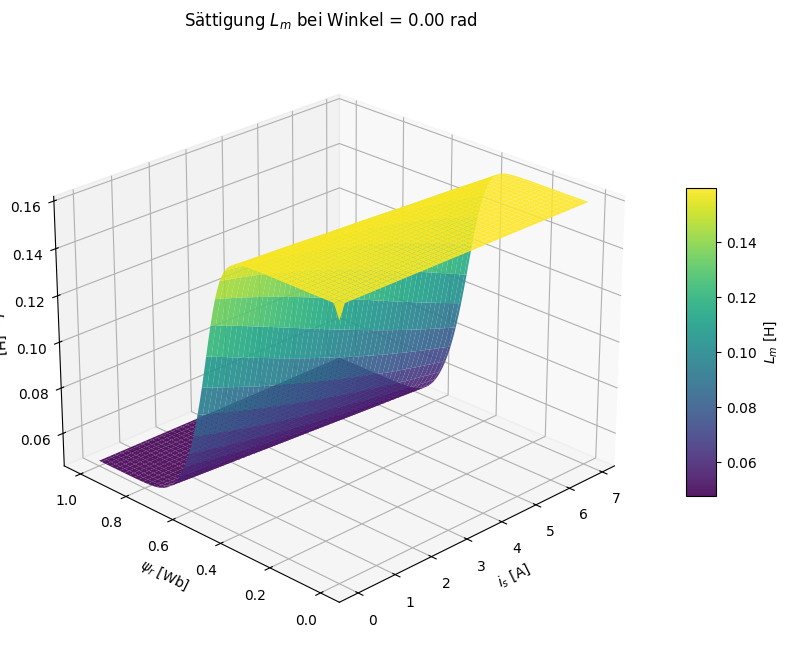

Statistiken für Winkel 0.00:
Max L_m: 0.1596 H
Min L_m: 0.0478 H


In [16]:
import matplotlib.pyplot as plt
from matplotlib import cm

angle_idx = 0  

I_S, PSI_R = jnp.meshgrid(i_s_grid_1d, psi_r_grid_1d)

Z = lm_grid[angle_idx, :, :].squeeze()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(I_S, PSI_R, Z, 
                       cmap='viridis', 
                       linewidth=0, 
                       antialiased=True,
                       alpha=0.9)

ax.set_xlabel('$i_s$ [A]')
ax.set_ylabel('$\psi_r$ [Wb]')
ax.set_zlabel('$L_m$ [H]')
ax.set_title(f'Sättigung $L_m$ bei Winkel = {angle_grid_1d[angle_idx]:.2f} rad')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='$L_m$ [H]')

ax.view_init(elev=25, azim=-135)

plt.show()

print(f"Statistiken für Winkel {angle_grid_1d[angle_idx]:.2f}:")
print(f"Max L_m: {Z.max():.4f} H")
print(f"Min L_m: {Z.min():.4f} H")

In [6]:
n_res = 100 
i_s_grid_1d = jnp.linspace(0.0, 5.5*1.25, n_res) 
psi_r_grid_1d = jnp.linspace(0.0, 0.8*1.25, n_res) 
angle_grid_1d = jnp.linspace(0, jnp.pi, n_res) 
@jax.jit
def solve_single_point(i_s_mag, psi_r_mag, angle, params):
    i_s_ab = jnp.array([i_s_mag, 0.0])
    psi_r_ab = jnp.array([psi_r_mag * jnp.cos(angle), psi_r_mag * jnp.sin(angle)])
    
    def root_fun(L_vec):
        return saturation_residuals_vector(L_vec, i_s_ab, psi_r_ab, params)

    solver = jaxopt.Broyden(fun=root_fun, maxiter=100, tol=1e-6)
    init_L = jnp.array(params['l_m'])
    sol = solver.run(init_L)
    L_final = sol.params
    
    psi_m_mag, i_r_ab = calc_flux_magnitudes(L_final, i_s_ab, psi_r_ab,params['l_sigr'])
    
    i_m_mag = jnp.linalg.norm(i_s_ab + i_r_ab)
    i_r_mag = jnp.linalg.norm(i_r_ab)
    
    return jnp.array([L_final, psi_m_mag, i_m_mag, i_r_mag, i_s_mag, psi_r_mag, angle])


v_solve = jax.vmap(jax.vmap(jax.vmap(solve_single_point, 
          in_axes=(0, None, None, None)), 
          in_axes=(None, 0, None, None)), 
          in_axes=(None, None, 0, None))


print("Berechne 3D-Sättigungsgrid...")
grid_results = v_solve(i_s_grid_1d, psi_r_grid_1d, angle_grid_1d, params)

# Extracting the grids
lm_grid       = grid_results[:, :, :, 0]
psi_m_grid    = grid_results[:, :, :, 1]
i_m_grid      = grid_results[:, :, :, 2]
i_r_grid      = grid_results[:, :, :, 3]
i_s_grid      = grid_results[:, :, :, 4]
psi_r_grid    = grid_results[:, :, :, 5]
angle_grid    = grid_results[:, :, :, 6]

Berechne 3D-Sättigungsgrid...


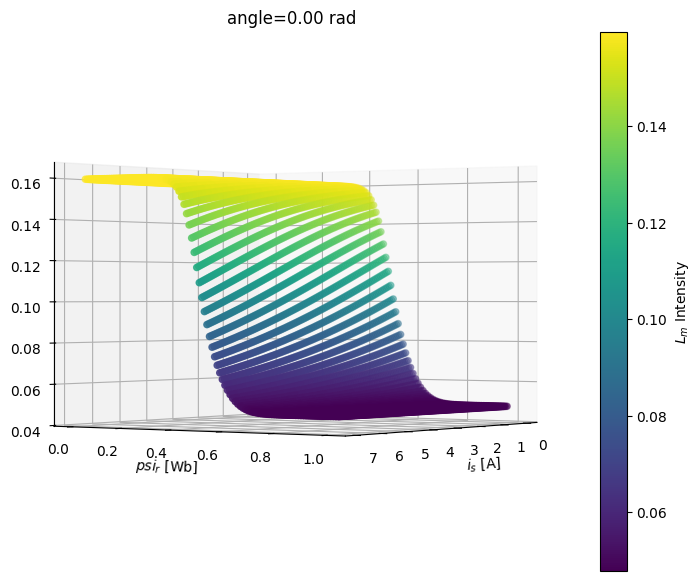

Max l_m: 0.15959999998982513
Min l_m: 0.047800000634144954


In [7]:
angle_idx = 0
psi_r_idx = n_res // 2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(i_s_grid[angle_idx, :, :].flatten(), psi_r_grid[angle_idx,:, :].flatten(), lm_grid[angle_idx,:, :].flatten(), c=lm_grid[angle_idx,:, :].flatten(), cmap='viridis')
ax.set_xlabel('$i_s$ [A]')
ax.set_ylabel('$psi_r$ [Wb]')
# ax.set_zlabel('$\psi_m$ [Wb]')
ax.set_title(f'angle={angle_grid_1d[angle_idx]:.2f} rad')
ax.view_init(elev=0, azim=35)
fig.colorbar(img, ax=ax, label='$L_m$ Intensity')
plt.show()

print("Max l_m:", lm_grid[angle_idx, :, :].flatten().max())
print("Min l_m:", lm_grid[angle_idx, :, :].flatten().min())

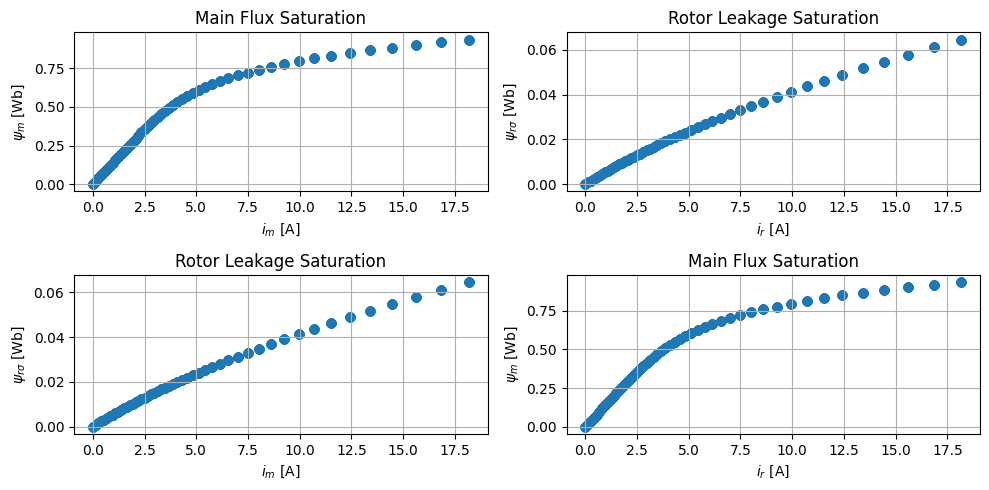

In [35]:
angle_idx = 0 
psi_r_idx = n_res // 2

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.scatter(i_m_grid[:, :, angle_idx].flatten(), psi_m_grid[:, :, angle_idx].flatten())
plt.title("Main Flux Saturation")
plt.xlabel("$i_m$ [A]")
plt.ylabel("$\psi_m$ [Wb]")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.scatter(i_r_grid[:, :, angle_idx].flatten(), psi_sigr_grid[:,:, angle_idx].flatten())
plt.title("Rotor Leakage Saturation")
plt.xlabel("$i_r$ [A]")
plt.ylabel("$\psi_{r\sigma}$ [Wb]")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.scatter(i_m_grid[:, :, angle_idx].flatten(), psi_sigr_grid[:,:, angle_idx].flatten())
plt.title("Rotor Leakage Saturation")
plt.xlabel("$i_m$ [A]")
plt.ylabel("$\psi_{r\sigma}$ [Wb]")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.scatter(i_r_grid[:, :, angle_idx].flatten(), psi_m_grid[:, :, angle_idx].flatten())
plt.title("Main Flux Saturation")
plt.xlabel("$i_r$ [A]")
plt.ylabel("$\psi_m$ [Wb]")
plt.grid(True)

plt.tight_layout()
plt.show()

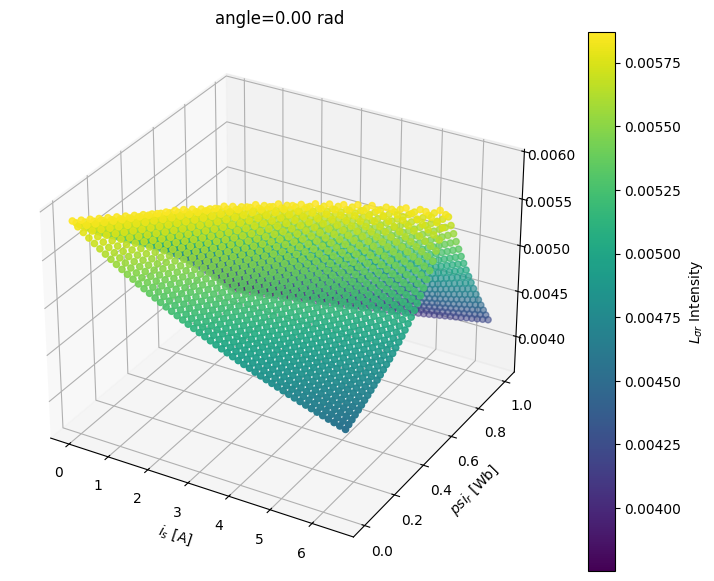

Max l_sigr: 0.00587
Min l_sigr: 0.003753141546327496


In [10]:
angle_idx = 0
psi_r_idx = n_res // 2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(i_s_grid[angle_idx, :, :].flatten(), psi_r_grid[angle_idx,:, :].flatten(), lsigr_grid[angle_idx,:, :].flatten(), c=lsigr_grid[angle_idx,:, :].flatten(), cmap='viridis')
ax.set_xlabel('$i_s$ [A]')
ax.set_ylabel('$psi_r$ [Wb]')
# ax.set_zlabel('$\psi_m$ [Wb]')
ax.set_title(f'angle={angle_grid_1d[angle_idx]:.2f} rad')

fig.colorbar(img, ax=ax, label='$L_{\sigma r}$ Intensity')
plt.show()

print("Max l_sigr:", lsigr_grid[angle_idx, :, :].flatten().max())
print("Min l_sigr:", lsigr_grid[angle_idx, :, :].flatten().min())

## Interpolators

In [250]:
angle_grid.shape, psi_r_grid.shape, i_s_grid.shape, lm_grid.shape, lsigr_grid.shape

((20, 20, 20), (20, 20, 20), (20, 20, 20), (20, 20, 20), (20, 20, 20))

In [281]:
points = (angle_grid_1d, psi_r_grid_1d, i_s_grid_1d)


LUT_interpolators = {
    "l_m": jax.scipy.interpolate.RegularGridInterpolator(
        points,
        lm_grid, 
        method="linear",
        bounds_error=False,
        fill_value=None  
    ),
    "l_sigr": jax.scipy.interpolate.RegularGridInterpolator(
        points,
        lsigr_grid,
        method="linear",
        bounds_error=False,
        fill_value=None
    )
}

@jax.jit
def get_L_saturated(i_s_mag, psi_r_mag, angle):
    query_point = jnp.array([angle, psi_r_mag, i_s_mag])
    
    l_m_sat = LUT_interpolators["l_m"](query_point)
    l_sigr_sat = LUT_interpolators["l_sigr"](query_point)
    
    return l_m_sat, l_sigr_sat

In [282]:
lm_grid.max(), lm_grid.min(), lsigr_grid.max(), lsigr_grid.min()

(Array(0.14375, dtype=float64),
 Array(0.08485755, dtype=float64),
 Array(0.00587, dtype=float64),
 Array(0.00382643, dtype=float64))

In [247]:
lm_grid.flatten()

Array([0.14375   , 0.14375   , 0.14375   , ..., 0.09065381, 0.09079054,
       0.0909263 ], dtype=float64)

In [296]:
LUT_interpolators["l_m"](jnp.array([0.0, 0.1, 5.0]))

Array([0.14369219], dtype=float64)

In [300]:
LUT_interpolators["l_sigr"](jnp.array([0.0, 0.1, 1.0]))

Array([0.0057715], dtype=float64)

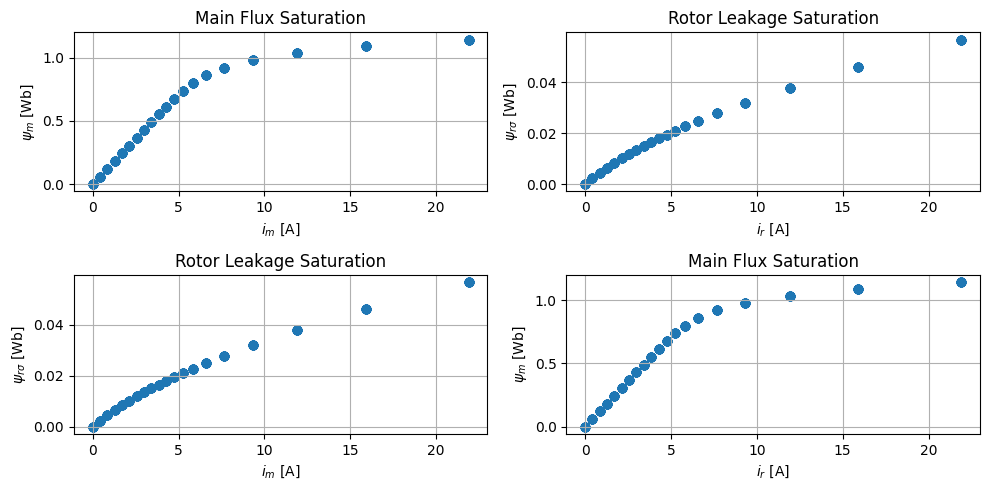

In [130]:
angle_idx = 0 
psi_r_idx = n_res // 2

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.scatter(i_m_grid[:, :, angle_idx].flatten(), psi_m_grid[:, :, angle_idx].flatten())
plt.title("Main Flux Saturation")
plt.xlabel("$i_m$ [A]")
plt.ylabel("$\psi_m$ [Wb]")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.scatter(i_r_grid[:, :, angle_idx].flatten(), psi_sigr_grid[:,:, angle_idx].flatten())
plt.title("Rotor Leakage Saturation")
plt.xlabel("$i_r$ [A]")
plt.ylabel("$\psi_{r\sigma}$ [Wb]")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.scatter(i_m_grid[:, :, angle_idx].flatten(), psi_sigr_grid[:,:, angle_idx].flatten())
plt.title("Rotor Leakage Saturation")
plt.xlabel("$i_m$ [A]")
plt.ylabel("$\psi_{r\sigma}$ [Wb]")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.scatter(i_r_grid[:, :, angle_idx].flatten(), psi_m_grid[:, :, angle_idx].flatten())
plt.title("Main Flux Saturation")
plt.xlabel("$i_r$ [A]")
plt.ylabel("$\psi_m$ [Wb]")
plt.grid(True)

plt.tight_layout()
plt.show()

## Plots as in Paper

In [143]:
def get_L_explicit(pm_mag, pr_mag, params):

    den_m = 1 + params['alpha'] * pm_mag**params['a'] + \
            params['gamma'] * params['l_m_u'] / (params['d'] + 2) * \
            pm_mag**params['c'] * pr_mag**(params['d'] + 2)
    
    den_r = 1 + params['beta'] * pr_mag**params['b'] + \
            params['gamma'] * params['l_sigr_u'] / (params['c'] + 2) * \
            pr_mag**params['d'] * pm_mag**(params['c'] + 2)
            
    return params['l_m_u'] / den_m, params['l_sigr_u'] / den_r

v_get_L = jax.vmap(get_L_explicit, in_axes=(0, None, None))

def plot_paper_style_curves(params):
    # Definition der Fluss-Bereiche
    psi_m_vec = jnp.linspace(0.001, 1.3, 200) 
    psi_r_sig_consts = [0.0, 0.02, 0.05] # Feste Rotorstreufluss-Werte

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for ps in psi_r_sig_consts:
        lm, _ = v_get_L(psi_m_vec, ps, params)
        im_vec = psi_m_vec / lm
        plt.plot(im_vec, psi_m_vec, label=r"$\psi_{r\sigma} = " + f"{ps}" + r"$ Wb")

    plt.title(r"Main Flux $\psi_m = f(i_m)$")
    plt.xlabel(r"$i_m$ [A]")
    plt.ylabel(r"$\psi_m$ [Wb]")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    psi_r_sig_vec = jnp.linspace(0.0, 0.1, 200)
    psi_m_fixed_vals = [0.5, 0.9, 1.1]

    for pm in psi_m_fixed_vals:
        v_get_L_r = jax.vmap(get_L_explicit, in_axes=(None, 0, None))
        lm, lsigr = v_get_L_r(pm, psi_r_sig_vec, params)
        
        ir_vec = psi_r_sig_vec / lsigr
        psi_m_effective = pm * (lm / params['l_m_u']) 
        
        plt.plot(ir_vec, psi_m_effective, label=r"$\psi_m \approx " + f"{pm}" + r"$ Wb")

    plt.title(r"Main Flux decrease due to $i_r$")
    plt.xlabel(r"$i_r$ [A]")
    plt.ylabel(r"$\psi_m$ [Wb]")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

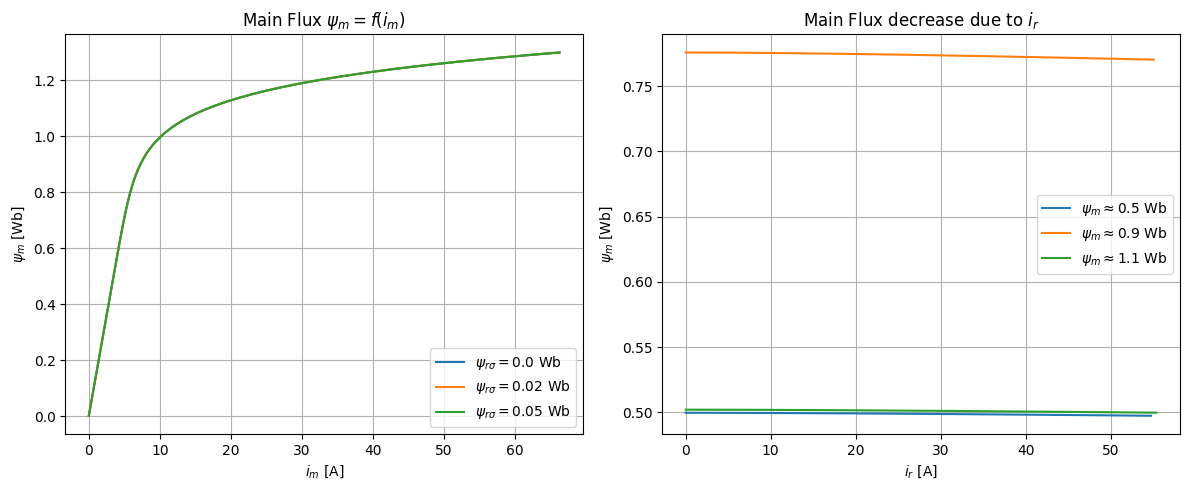

In [144]:
plot_paper_style_curves(params=params)

In [116]:
i_m_grid[:, psi_r_idx, angle_idx]

Array([4.28347804, 4.28347804, 4.28347804, 4.28347804, 4.28347804,
       4.28347804, 4.28347804, 4.28347804, 4.28347804, 4.28347804,
       4.28347804, 4.28347804, 4.28347804, 4.28347804, 4.28347804,
       4.28347804, 4.28347804, 4.28347804, 4.28347804, 4.28347804],      dtype=float64)

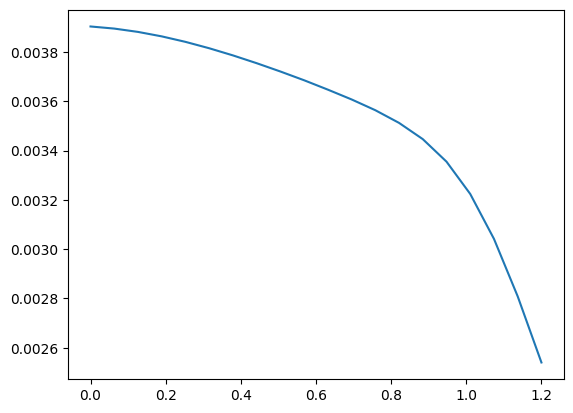

In [107]:
plt.plot(psi_r_grid,lsigr_grid[10,:,20])

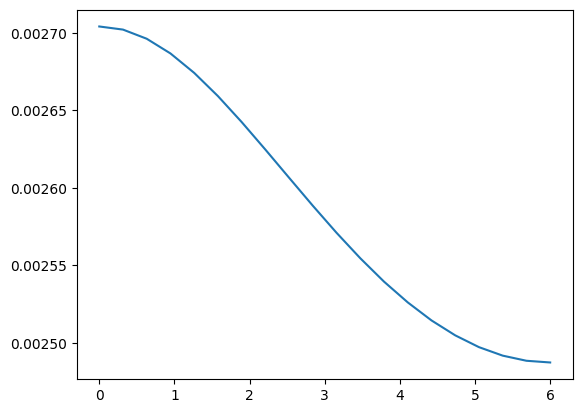

In [89]:
plt.plot(i_s_grid,lsigr_grid[:,20,10])

In [54]:
grid_results[:,0,0]

Array([[0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587],
       [0.14375, 0.00587]], dtype=float64)

In [44]:
print(params['l_m_u'], params['l_sigr_u'])

0.14375 0.00587


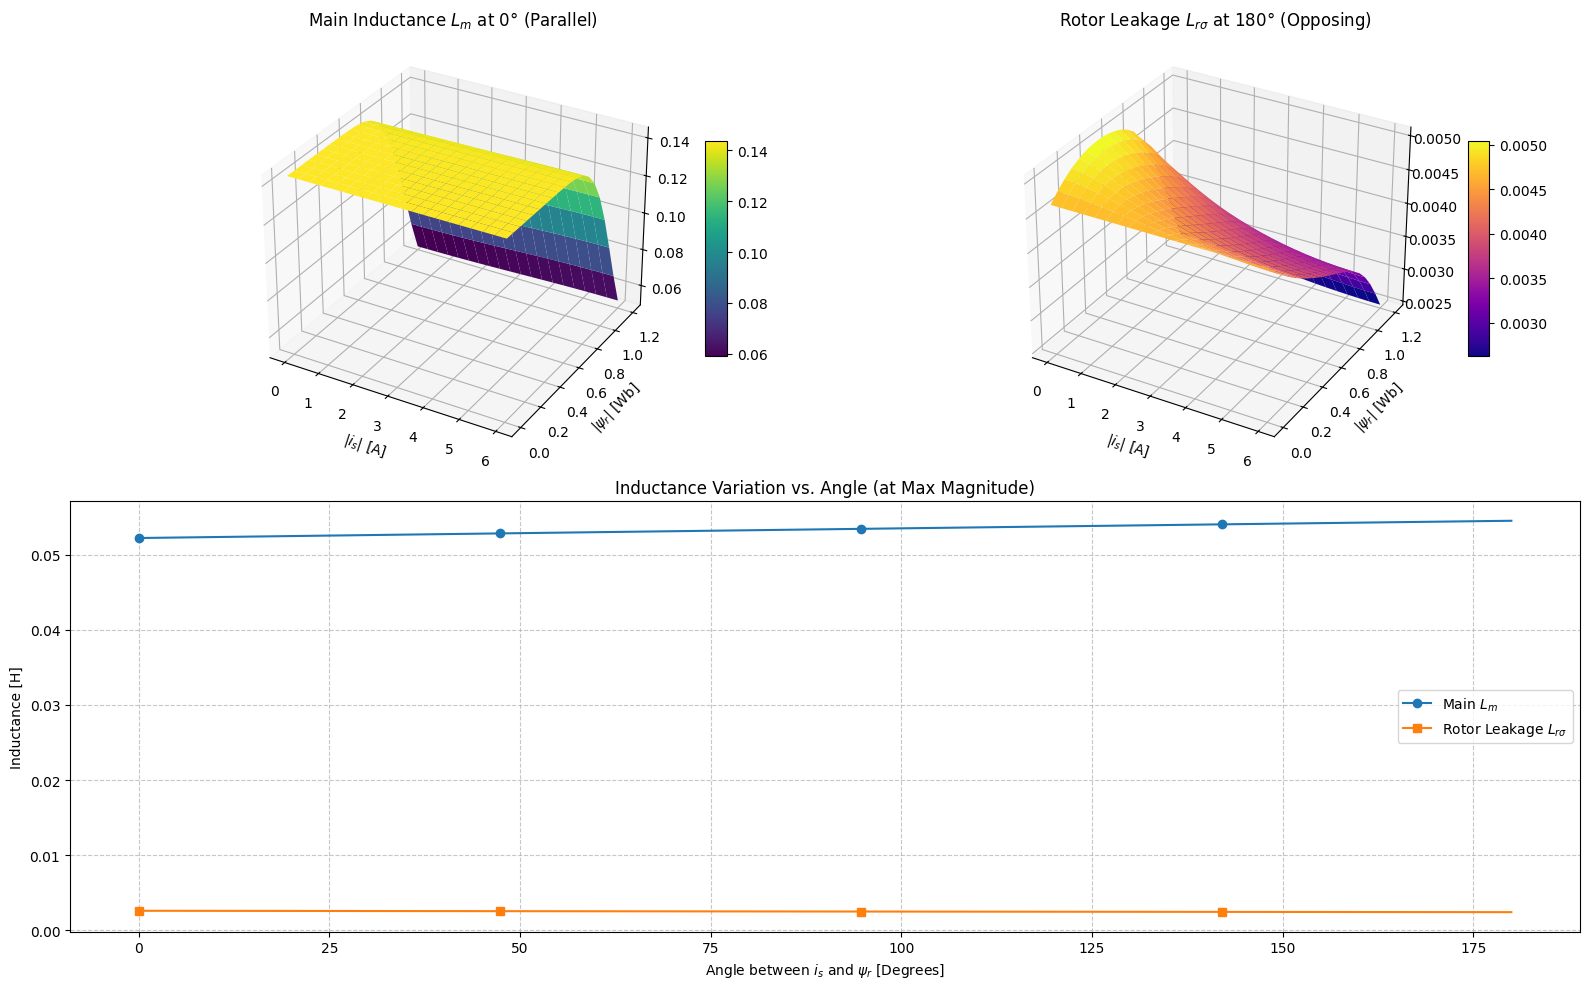

In [50]:
import matplotlib.pyplot as plt
import numpy as np


lm_data = np.array(lm_grid)
lsigr_data = np.array(lsigr_grid)


X, Y = np.meshgrid(i_s_grid, psi_r_grid)

fig = plt.figure(figsize=(16, 10))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')

surf1 = ax1.plot_surface(X, Y, np.mean(lm_data[:, :, :],axis=-1).T, cmap='viridis', edgecolor='none')
ax1.set_title("Main Inductance $L_m$ at 0° (Parallel)")
ax1.set_xlabel("$|i_s|$ [A]")
ax1.set_ylabel("$|\psi_r|$ [Wb]")
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, np.mean(lsigr_data[:, :, :],axis=-1).T, cmap='plasma', edgecolor='none')
ax2.set_title("Rotor Leakage $L_{r\sigma}$ at 180° (Opposing)")
ax2.set_xlabel("$|i_s|$ [A]")
ax2.set_ylabel("$|\psi_r|$ [Wb]")
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

ax3 = fig.add_subplot(2, 1, 2)

angle_deg = np.degrees(angle_grid)
ax3.plot(angle_deg, lm_data[-1, -1, :], label="Main $L_m$", marker='o', markevery=5)
ax3.plot(angle_deg, lsigr_data[-1, -1, :], label="Rotor Leakage $L_{r\sigma}$", marker='s', markevery=5)

ax3.set_title("Inductance Variation vs. Angle (at Max Magnitude)")
ax3.set_xlabel("Angle between $i_s$ and $\psi_r$ [Degrees]")
ax3.set_ylabel("Inductance [H]")
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [61]:
PRNGKey = jax.vmap(jax.random.PRNGKey)(np.random.randint(0, 2**31, size=(BATCH_SIZE,)))
obs, motor_env_state = new_motor_env.reset(new_motor_env.env_properties,PRNGKey[0]) #PRNGKey
motor_env_state.physical_state

IM.PhysicalState(u_alpha_buffer=0.0, u_beta_buffer=0.0, i_s_alpha=Array(-2.45965644, dtype=float64), i_s_beta=Array(0.61998907, dtype=float64), psi_r_alpha=Array(-0.35776821, dtype=float64), psi_r_beta=Array(0.09018023, dtype=float64), epsilon=Array(-1.68680356, dtype=float64), omega_el=Array(297.40391159, dtype=float64), torque=Array(-7.99999464e-17, dtype=float64))

In [40]:
def gym_electric_motor_step(params,omega,i_alpha,i_beta,psi_alpha,psi_beta,eps,u_s_alpha,u_s_beta):
    l_s = params.l_m  + params.l_sigs 
    l_r = params.l_m  + params.l_sigr
    sigma = (l_s * l_r - params.l_m ** 2) / (l_s * l_r)
    tau_r = l_r / params.r_r
    tau_sig = sigma * l_s / (params.r_s + params.r_r * (params.l_m ** 2) / (l_r**2))

    model_constants = np.array([
        # omega, i_alpha, i_beta, psi_ralpha, psi_rbeta, omega * psi_ralpha, omega * psi_rbeta, u_salpha, u_sbeta, u_ralpha, u_rbeta,
        [0, -1 / tau_sig, 0,params.l_m * params.r_r / (sigma * l_s * l_r ** 2), 0, 0,
            +params.l_m * params.p / (sigma * l_r * l_s), 1 / (sigma * l_s), 0,
            -params.l_m / (sigma * l_r * l_s), 0, ],  # i_ralpha_dot
        [0, 0, -1 / tau_sig, 0,
            params.l_m * params.r_r / (sigma * l_s * l_r ** 2),
            -params.l_m * params.p / (sigma * l_r * l_s), 0, 0,
            1 / (sigma * l_s), 0, -params.l_m / (sigma * l_r * l_s), ],
        # i_rbeta_dot
        [0, params.l_m/ tau_r, 0, -1 / tau_r, 0, 0, -params.p, 0, 0, 1,
            0, ],  # psi_ralpha_dot
        [0, 0, params.l_m / tau_r, 0, -1 / tau_r, params.p, 0, 0, 0, 0, 1, ],
        # psi_rbeta_dot
        [params.p, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ],  # epsilon_dot
    ])

    dstate_dt= np.matmul(
            model_constants,
            np.array(
                [
                    # omega, i_alpha, i_beta, psi_ralpha, psi_rbeta, omega * psi_ralpha, omega * psi_rbeta, u_salpha, u_sbeta, u_ralpha, u_rbeta,
                    omega,
                    i_alpha,
                    i_beta,
                    psi_alpha,
                    psi_beta,
                    omega * psi_alpha,
                    omega * psi_beta,
                    u_s_alpha,
                    u_s_beta,
                    0.0,
                    0.0,
                ]
            ),
        )
    i_alpha_k1 = i_alpha + dstate_dt[0] * 1e-4
    i_beta_k1 = i_beta + dstate_dt[1] * 1e-4
    psi_alpha_k1 = psi_alpha + dstate_dt[2] * 1e-4
    psi_beta_k1 = psi_beta + dstate_dt[3] * 1e-4
    epsilon_k1 = eps + dstate_dt[4] * 1e-4

    return np.array([i_alpha_k1, i_beta_k1, psi_alpha_k1, psi_beta_k1, epsilon_k1])

In [62]:
action=jnp.array([0.5,0.32])
action_denorm= new_motor_env.env_properties.action_normalizations.u_alpha.denormalize(action)
gymstate=gym_electric_motor_step(new_motor_env.env_properties.static_params,
                                 motor_env_state.physical_state.omega_el/2,
                                 motor_env_state.physical_state.i_s_alpha, 
                                 motor_env_state.physical_state.i_s_beta,
                                 motor_env_state.physical_state.psi_r_alpha,
                                 motor_env_state.physical_state.psi_r_beta,
                                 motor_env_state.physical_state.epsilon,
                                 action_denorm[0],
                                 action_denorm[1])

In [63]:
bs_next,next_state=new_motor_env.step(motor_env_state,action,env_properties=new_motor_env.env_properties)

In [64]:
print(jnp.isclose(jnp.array(gymstate[0]),next_state.physical_state.i_s_alpha))
print(jnp.isclose(jnp.array(gymstate[1]),next_state.physical_state.i_s_beta))
print(jnp.isclose(jnp.array(gymstate[2]),next_state.physical_state.psi_r_alpha))
print(jnp.isclose(jnp.array(gymstate[3]),next_state.physical_state.psi_r_beta))
print(jnp.isclose(jnp.array(gymstate[4]),next_state.physical_state.epsilon))

True
True
True
True
True


### Other small tests

In [ ]:
obs, motor_env_state = new_motor_env.vmap_reset() #PRNGKey
next_state=motor_env_state
i_dqs=[]
for _ in range(25):
    act=jnp.repeat(jnp.array([-1.0,1.0])[:,None],BATCH_SIZE,axis=1).T
    obs_next,next_state=new_motor_env.vmap_step(next_state,act)
    i_dqs.append(obs_next[0,0:2])

Text(0, 0.5, 'i_beta')

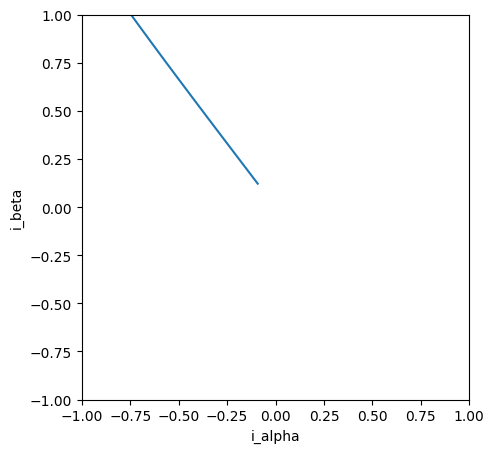

In [20]:
fig,ax=plt.subplots(1,1,figsize=(5,5))
ax.plot(jnp.array(i_dqs)[:,0],jnp.array(i_dqs)[:,1])
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_xlabel("i_alpha")
ax.set_ylabel("i_beta")


### PMSM with GymWrapper

In [6]:
from exciting_environments import GymWrapper

In [ ]:
gym_pmsm= GymWrapper(env=new_motor_env)

In [ ]:
gym_pmsm.reset()
i_dqs2=[]
for _ in range(1000):
    act=jnp.repeat(jnp.array([0.03,0.03])[:,None],BATCH_SIZE,axis=1).T
    obs_next,_,_,_=gym_pmsm.step(act)
    i_dqs2.append(obs_next[0,0:2])

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(5,5))
ax.plot(jnp.array(i_dqs2)[:,0],jnp.array(i_dqs2)[:,1])
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_xlabel("i_d")
ax.set_ylabel("i_q")